In [1]:
# Install OCR dependencies.
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract easyocr opencv-python pillow matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 27.5 MB/s eta 0:00:00


In [2]:
# Import packages and verify the OCR engine.
import os
import re

import cv2
import easyocr
import matplotlib.pyplot as plt
import pandas as pd
import pytesseract
from PIL import Image, ImageDraw

!tesseract --version
print("Libraries are ready.")

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8
All libraries installed successfully!


In [3]:
# Upload the sample image used for the first OCR check.
from google.colab import files

uploaded_files = files.upload()

Saving images.png to images.png


In [4]:
# Set the initial uploaded image path.
image_file = "/content/images.png"

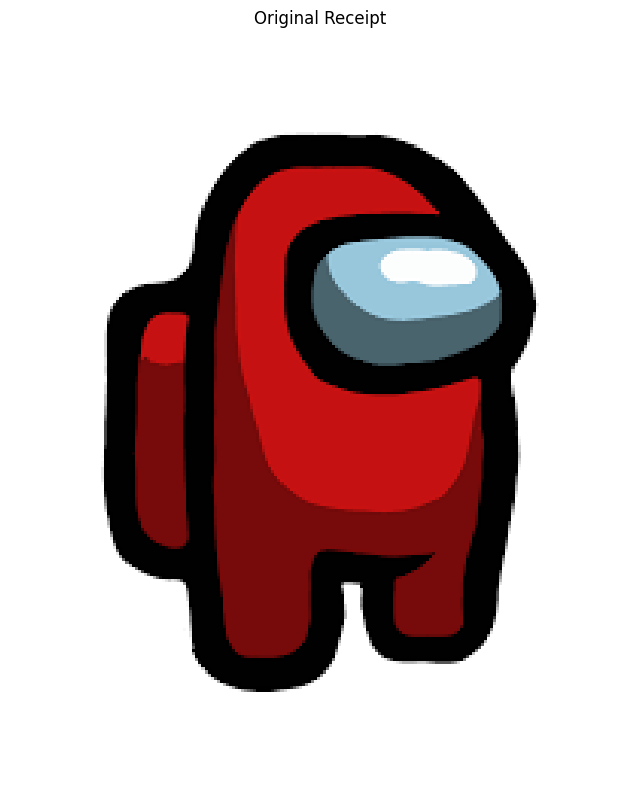

In [6]:
# Display the uploaded receipt image.
receipt_image = Image.open(image_file)

plt.figure(figsize=(8, 10))
plt.imshow(receipt_image)
plt.title("Original Receipt")
plt.axis("off")
plt.show()

In [7]:
# Extract text with Tesseract from the uploaded image.
raw_text = pytesseract.image_to_string(receipt_image)

print("=== EXTRACTED TEXT (TESSERACT) ===")
print(raw_text)

=== EXTRACTED TEXT (TESSERACT) ===
 



In [8]:
# Review word-level OCR confidence values.
ocr_table = pytesseract.image_to_data(receipt_image, output_type="dict")
confidence_df = pd.DataFrame(ocr_table)
confidence_df = confidence_df[confidence_df["text"].astype(str).str.strip() != ""]
confidence_df = confidence_df[confidence_df["conf"] != -1]

print(confidence_df[["text", "conf"]].head(20))
print(f"\nAverage Confidence: {confidence_df['conf'].astype(float).mean():.2f}%")
print(f"Words detected: {len(confidence_df)}")

Empty DataFrame
Columns: [text, conf]
Index: []

Average Confidence: nan%
Words detected: 0


In [10]:
# Generate five clean receipt samples for the lab.
os.makedirs("/content/week5_ocr_basics/Receipts", exist_ok=True)

sample_receipts = [
    {
        "filename": "receipt1.png",
        "lines": [
            "FRESH MART",
            "123 Main Street, Islamabad",
            "Phone: 051-1234567",
            "------------------------------",
            "Date: 04/18/2026",
            "Time: 08:42 PM",
            "Milk                 2.50",
            "Bread                1.80",
            "Eggs                 3.20",
            "Rice                 5.00",
            "Tax                  0.85",
            "TOTAL               13.35",
            "Thank you for shopping!"
        ]
    },
    {
        "filename": "receipt2.png",
        "lines": [
            "CITY PHARMACY",
            "Blue Area, Islamabad",
            "Phone: 051-7654321",
            "------------------------------",
            "Date: 2026-04-17",
            "Time: 02:15 PM",
            "Painkiller           4.50",
            "Vitamins             7.25",
            "Bandage              2.00",
            "Tax                  0.70",
            "TOTAL               14.45",
            "Get well soon!"
        ]
    },
    {
        "filename": "receipt3.png",
        "lines": [
            "BOOK NOOK",
            "F-7 Markaz, Islamabad",
            "Phone: 051-9988776",
            "------------------------------",
            "Date: 04/16/2026",
            "Time: 06:10 PM",
            "Notebook             3.00",
            "Pen Set              2.75",
            "Novel                8.50",
            "Tax                  0.95",
            "TOTAL               15.20",
            "Visit again!"
        ]
    },
    {
        "filename": "receipt4.png",
        "lines": [
            "TECH HUB",
            "G-8 Center, Islamabad",
            "Phone: 051-2233445",
            "------------------------------",
            "Date: 2026/04/15",
            "Time: 11:05 AM",
            "USB Cable            5.00",
            "Mouse Pad            3.50",
            "Charger             12.00",
            "Tax                  1.50",
            "TOTAL               22.00",
            "Warranty included"
        ]
    },
    {
        "filename": "receipt5.png",
        "lines": [
            "GREEN GROCERS",
            "Sector I-8, Islamabad",
            "Phone: 051-5566778",
            "------------------------------",
            "Date: 04-14-2026",
            "Time: 09:20 AM",
            "Apples               4.20",
            "Bananas              2.30",
            "Tomatoes             3.40",
            "Potatoes             2.10",
            "Tax                  0.60",
            "TOTAL               12.60",
            "Fresh every day!"
        ]
    }
]

for receipt in sample_receipts:
    canvas = Image.new("RGB", (800, 600), color="white")
    drawer = ImageDraw.Draw(canvas)
    top = 40
    for entry in receipt["lines"]:
        drawer.text((50, top), entry, fill="black")
        top += 40
    canvas.save(os.path.join("/content/week5_ocr_basics/Receipts", receipt["filename"]))

print("Receipt images created successfully.")

5 receipt images created successfully.


In [11]:
# List the generated receipt files.
print(os.listdir("/content/week5_ocr_basics/Receipts"))

['receipt2.png',
 'receipt3.png',
 'receipt1.png',
 'receipt5.png',
 'receipt4.png']

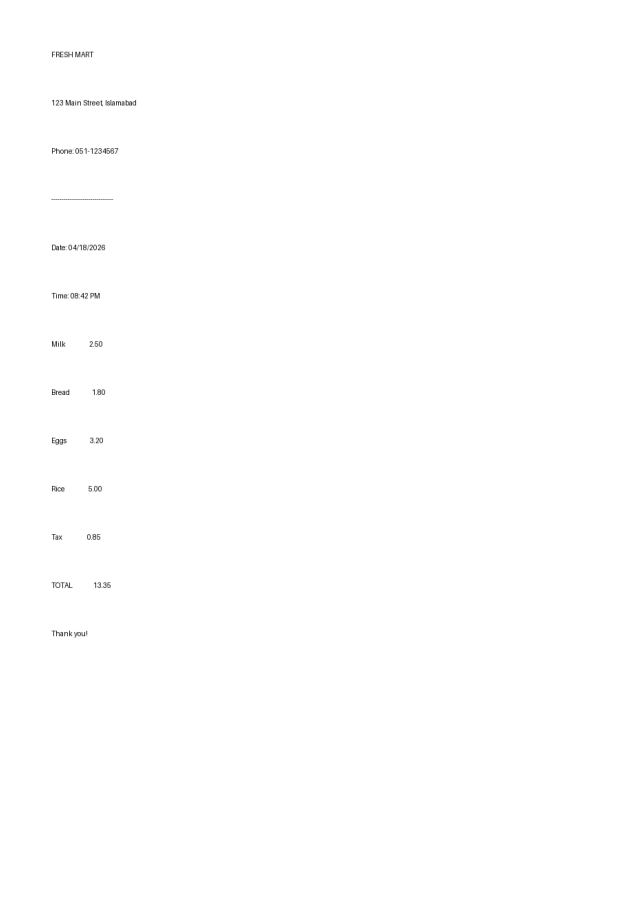

FRESH MART

128 Main Stet Islamabad

Phone: 051-1234567

Date: 04/18/2028

Time: 08:42 PM
Mik 250
Bread 180
Fags 3.20
Rice = 500
Tex 085
TOTAL «1335,

Thankyou!



In [14]:
# Open one generated sample and preview its OCR text.
sample_path = "/content/week5_ocr_basics/Receipts/receipt1.png"
preview_image = Image.open(sample_path)

plt.figure(figsize=(8, 12))
plt.imshow(preview_image)
plt.axis("off")
plt.show()

print(pytesseract.image_to_string(preview_image))

In [15]:
# Measure confidence on the generated sample image.
sample_data = pytesseract.image_to_data(preview_image, output_type="dict")
sample_df = pd.DataFrame(sample_data)
sample_df = sample_df[sample_df["text"].astype(str).str.strip() != ""]
sample_df = sample_df[sample_df["conf"] != -1]

print("=== CONFIDENCE SCORES ===")
print(sample_df[["text", "conf"]].head(20))
print(f"\nAverage Confidence: {sample_df['conf'].astype(float).mean():.2f}%")
print(f"Words detected: {len(sample_df)}")

=== CONFIDENCE SCORES ===
           text  conf
4         FRESH    69
5          MART    91
9           128    87
10         Main    90
11         Stet    61
12    Islamabad    38
16       Phone:    74
17  051-1234567    26
21        Date:    31
22   04/18/2028    31
26        Time:    54
27        08:42    54
28           PM    68
30          Mik    80
31          250    22
33        Bread    67
34          180    35
36         Fags    46
37         3.20    30
39         Rice    53

Average Confidence: 55.04%
Words detected: 27


In [16]:
# Initialize EasyOCR once for later comparisons.
reader = easyocr.Reader(["en"])
print("EasyOCR initialized!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR initialized!


In [17]:
# Run EasyOCR on the sample receipt.
easy_items = reader.readtext(sample_path)

print("=== EasyOCR RESULTS ===")
for _, detected_text, score in easy_items:
    print(f"Text: {detected_text:20s} | Confidence: {score:.2f}")

easy_full_text = " \".join([item[1] for item in easy_items])
print("\n=== FULL EXTRACTED TEXT ===")
print(easy_full_text)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RESULTS ===
Text: FRESH MART           | Confidence: 0.87
Text: 123 Main Street Islamabad | Confidence: 0.86
Text: Phone: 051-1234567   | Confidence: 0.69
Text: Date. 04'18/2026     | Confidence: 0.27
Text: Time: 08.42 PM       | Confidence: 0.69
Text: Milk                 | Confidence: 1.00
Text: 2.50                 | Confidence: 0.58
Text: Bread                | Confidence: 1.00
Text: 1.80                 | Confidence: 0.99
Text: Eggs                 | Confidence: 1.00
Text: Rice                 | Confidence: 1.00
Text: TOTAL                | Confidence: 0.98
Text: 13.35                | Confidence: 0.89
Text: Thankyoul            | Confidence: 1.00

=== FULL EXTRACTED TEXT ===
FRESH MART 123 Main Street Islamabad Phone: 051-1234567 Date. 04'18/2026 Time: 08.42 PM Milk 2.50 Bread 1.80 Eggs Rice TOTAL 13.35 Thankyoul


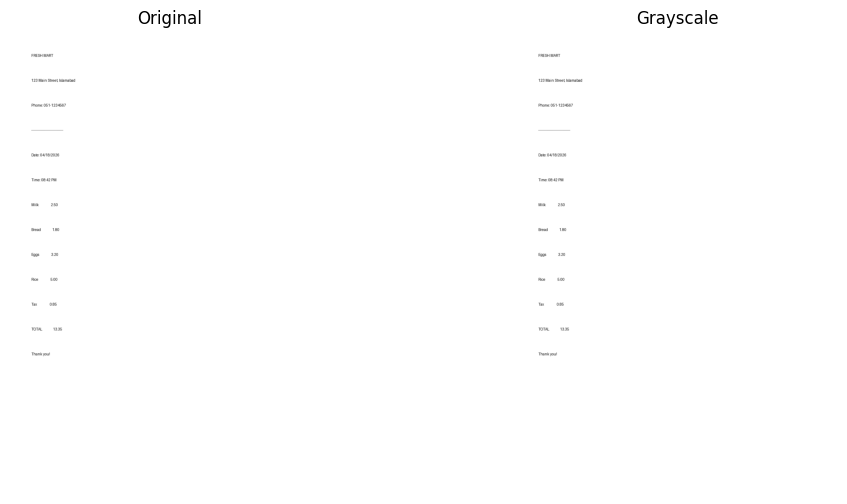

In [18]:
# Convert the image to grayscale for preprocessing.
source_bgr = cv2.imread(sample_path)
grayscale = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(grayscale, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

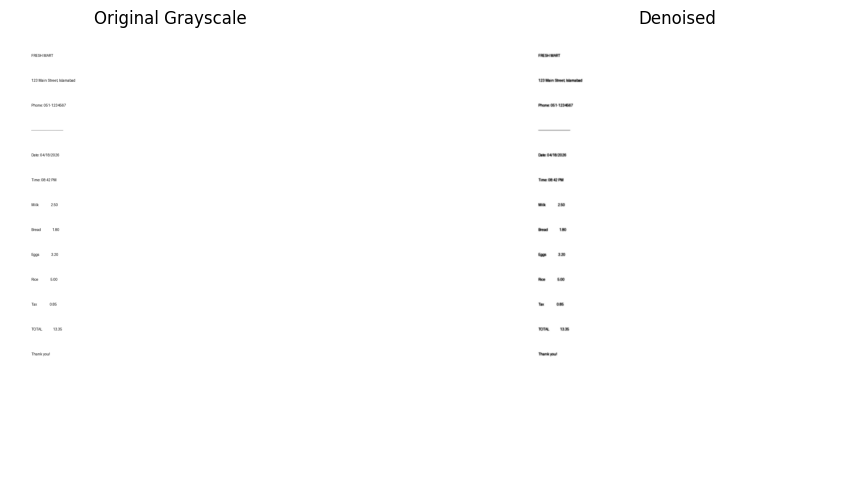

In [19]:
# Reduce noise before thresholding.
smoothed = cv2.GaussianBlur(grayscale, (5, 5), 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(grayscale, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(smoothed, cmap="gray")
plt.title("Denoised")
plt.axis("off")
plt.show()

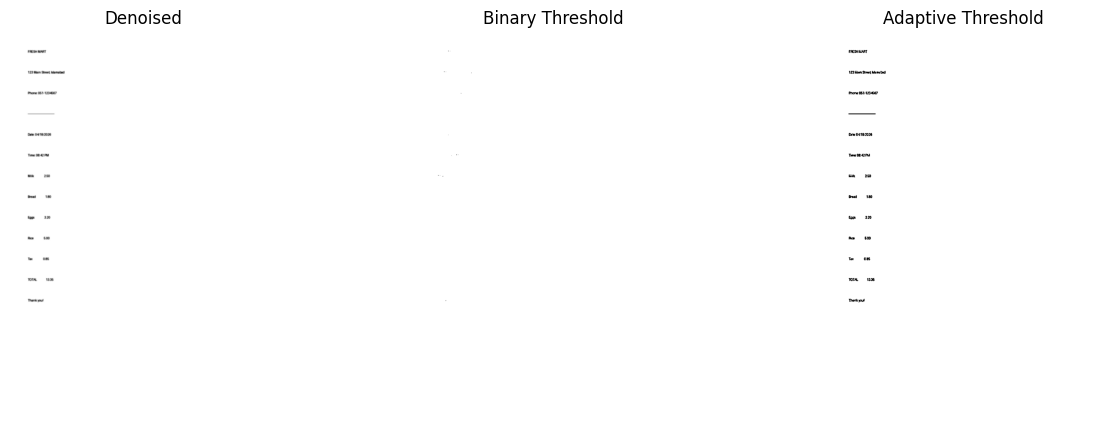

In [20]:
# Apply fixed and adaptive thresholding.
_, binary_view = cv2.threshold(smoothed, 127, 255, cv2.THRESH_BINARY)
adaptive_view = cv2.adaptiveThreshold(
    smoothed,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2,
)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(smoothed, cmap="gray")
plt.title("Denoised")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(binary_view, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(adaptive_view, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

In [21]:
# Compare OCR on the original and preprocessed image.
original_text = pytesseract.image_to_string(Image.fromarray(cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB)))
processed_text = pytesseract.image_to_string(Image.fromarray(adaptive_view))

print("=== ORIGINAL IMAGE OCR ===")
print(original_text)
print("Characters:", len(original_text))
print("\n=== PREPROCESSED IMAGE OCR ===")
print(processed_text)
print("Characters:", len(processed_text))

extra_chars = len(processed_text) - len(original_text)
print(f"\nImprovement: +{extra_chars} chars")
print(f"Percentage Improvement: {(extra_chars / max(len(original_text), 1)) * 100:.1f}%")

=== ORIGINAL IMAGE OCR ===
FRESH MART

128 Main Stet Islamabad

Phone: 051-1234567

Date: 04/18/2028

Time: 08:42 PM
Mik 250
Bread 180
Fags 3.20
Rice = 500
Tex 085
TOTAL «1335,

Thankyou!

Characters: 162

=== PREPROCESSED IMAGE OCR ===
reset

123 Alun Sve bless

Prone 0614173647
Greo4te2078
Tae 08 2FUL
wx 280
Gus 10
fa 320
fee 500,

Tx ts
TO 136

Thank yo

Characters: 123

Improvement: +-39 chars
Percentage Improvement: -24.1%


In [22]:
# Reconfirm the reader object for later steps.
reader = easyocr.Reader(["en"])
print("EasyOCR initialized!")

EasyOCR initialized!


In [23]:
# Run EasyOCR again after preprocessing review.
second_pass = reader.readtext(sample_path)

print("=== EasyOCR RESULTS ===")
for _, detected_text, score in second_pass:
    print(f"Text: {detected_text:20s} | Confidence: {score:.2f}")

joined_text = " \".join([item[1] for item in second_pass])
print("\n=== FULL EXTRACTED TEXT ===")
print(joined_text)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RESULTS ===
Text: FRESH MART           | Confidence: 0.87
Text: 123 Main Street Islamabad | Confidence: 0.86
Text: Phone: 051-1234567   | Confidence: 0.69
Text: Date. 04'18/2026     | Confidence: 0.27
Text: Time: 08.42 PM       | Confidence: 0.69
Text: Milk                 | Confidence: 1.00
Text: 2.50                 | Confidence: 0.58
Text: Bread                | Confidence: 1.00
Text: 1.80                 | Confidence: 0.99
Text: Eggs                 | Confidence: 1.00
Text: Rice                 | Confidence: 1.00
Text: TOTAL                | Confidence: 0.98
Text: 13.35                | Confidence: 0.89
Text: Thankyoul            | Confidence: 1.00

=== FULL EXTRACTED TEXT ===
FRESH MART 123 Main Street Islamabad Phone: 051-1234567 Date. 04'18/2026 Time: 08.42 PM Milk 2.50 Bread 1.80 Eggs Rice TOTAL 13.35 Thankyoul


In [25]:
# Build a reusable OCR comparison helper.
def compare_ocr_methods(image_path):
    frame = cv2.imread(image_path)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    soft_frame = cv2.GaussianBlur(gray_frame, (5, 5), 0)
    prepared = cv2.adaptiveThreshold(
        soft_frame,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2,
    )
    tesseract_text = pytesseract.image_to_string(Image.fromarray(prepared))
    easy_segments = reader.readtext(image_path)
    easy_text = " \".join([segment[1] for segment in easy_segments])
    return tesseract_text, easy_text

In [26]:
# Reuse the same helper definition in a clean form.
def compare_ocr_methods(image_path):
    frame = cv2.imread(image_path)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    soft_frame = cv2.GaussianBlur(gray_frame, (5, 5), 0)
    prepared = cv2.adaptiveThreshold(
        soft_frame,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2,
    )
    tesseract_text = pytesseract.image_to_string(Image.fromarray(prepared))
    easy_segments = reader.readtext(image_path)
    easy_text = " \".join([segment[1] for segment in easy_segments])
    return tesseract_text, easy_text

In [32]:
# Extract merchant, date, and total from OCR text.
def parse_receipt(text):
    cleaned_lines = [line.strip() for line in text.splitlines() if line.strip()]
    store_name = cleaned_lines[0] if cleaned_lines else "Not Found"

    found_date = re.search(r"(\d{2}[/-]\d{2}[/-]\d{4}|\d{4}[/-]\d{2}[/-]\d{2})", text)
    date_value = found_date.group(0) if found_date else "Not Found"

    found_total = re.search(r"(TOTAL|Total|total)[^\d]*(\d+\.\d{2})", text)
    if not found_total:
        found_total = re.search(r"(\d+\.\d{2})\s*$", text, re.MULTILINE)

    if found_total and len(found_total.groups()) > 1:
        total_value = found_total.group(2)
    elif found_total:
        total_value = found_total.group(1)
    else:
        total_value = "Not Found"

    return {
        "merchant": store_name,
        "date": date_value,
        "total": total_value,
    }

In [33]:
# Process all five receipts and summarize the results.
receipt_files = [
    "/content/week5_ocr_basics/Receipts/receipt1.png",
    "/content/week5_ocr_basics/Receipts/receipt2.png",
    "/content/week5_ocr_basics/Receipts/receipt3.png",
    "/content/week5_ocr_basics/Receipts/receipt4.png",
    "/content/week5_ocr_basics/Receipts/receipt5.png",
]

summary_rows = []
for receipt_path in receipt_files:
    tess_text, easy_text = compare_ocr_methods(receipt_path)
    parsed_fields = parse_receipt(tess_text)
    summary_rows.append(
        {
            "file": os.path.basename(receipt_path),
            "merchant": parsed_fields["merchant"],
            "date": parsed_fields["date"],
            "total": parsed_fields["total"],
            "tesseract_chars": len(tess_text),
            "easyocr_chars": len(easy_text),
        }
    )

results_df = pd.DataFrame(summary_rows)
print(results_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

,file,merchant,date,total,tesseract_chars,easyocr_chars
0,receipt1.png,reset,Not Found,Not Found,123,140
1,receipt2.png,SUPEA STORE,Not Found,Not Found,80,152
2,receipt3.png,ciTvcasiscany,Not Found,Not Found,134,149
3,receipt4.png,GAL hbeeutad,Not Found,Not Found,99,144
4,receipt5.png,omrsne,Not Found,Not Found,126,148


In [30]:
# Save the final comparison table.
results_df.to_csv("/content/week5_ocr_basics/ocr_results.csv", index=False)
print("Results saved!")

Results saved!


In [35]:
# Write a short project summary to a text file.
paragraph = """
# Lab 5 - OCR Basics

## Objective
This lab shows OCR on receipt images with Tesseract and EasyOCR, supported by OpenCV preprocessing.

## Tasks Completed
- Installed and configured Tesseract and EasyOCR
- Extracted text from receipt images
- Calculated confidence scores
- Converted images to grayscale
- Applied Gaussian blur
- Applied binary and adaptive thresholding
- Compared OCR before and after preprocessing
- Built a regex-based receipt parser
- Processed 5 receipt images
- Saved results in CSV format

## Files Included
- week5_ocr_basics.ipynb
- Receipts/receipt1.png ... receipt5.png
- ocr_results.csv
"""

with open("/content/week5_ocr_basics/readme.md", "w") as handle:
    handle.write(paragraph)

print("readme.md created successfully!")

Content added to README successfully!
